In [5]:
# Cài đặt các thư viện cần thiết
!pip install transformers pandas numpy matplotlib seaborn scikit-learn tensorflow keras torch nltk joblib pydot torchviz torchinfo
!sudo apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!python --version

Python 3.11.13


In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [7]:
# Thiết lập device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# LOADING DATASET

In [8]:
df = pd.read_csv('/content/drive/MyDrive/Phising-DataSet/dataset_phishing.csv')
df.head(10)

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
5,http://appleid.apple.com-app.es/,32,24,0,3,1,0,0,0,0,...,1,1,1,0,-1,0,0,1,0,phishing
6,http://www.mutuo.it,19,12,0,2,0,0,0,0,0,...,0,1,0,170,7529,0,0,0,1,legitimate
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
8,http://vamoaestudiarmedicina.blogspot.com/,42,34,0,2,0,0,0,0,0,...,1,1,0,371,7298,0,0,0,5,legitimate
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate


In [9]:
#Gán nhãn cho dataset với "phishing = 1", "legitimate = 0"
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df['labels'] = le.fit_transform(df['status'])

In [10]:
df[['status','labels']].head(10)

,status,labels
0,legitimate,0
1,phishing,1
2,phishing,1
3,legitimate,0
4,legitimate,0
5,phishing,1
6,legitimate,0
7,phishing,1
8,legitimate,0
9,legitimate,0


In [11]:
Y1 = df['labels']
X1 = df.drop(columns = ['url','labels','status'])

In [12]:
X1.head(2)

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,37,19,0,3,0,0,0,0,0,0,...,0,0,1,0,45,-1,0,1,1,4
1,77,23,1,1,0,0,0,0,0,0,...,0,1,0,0,77,5767,0,0,1,2


In [13]:
Y1.head(2)

,labels
0,0
1,1


In [14]:
#Dữ liệu huấn luyện ko có đặc trưng
X2 = df['url']
X2.head(2)

,url
0,http://www.crestonwood.com/router.php
1,http://shadetreetechnology.com/V4/validation/a...


# CREATING DATASET WITH PRIOR FEATURE EXTRACTION(CNN-LSTM)

In [ ]:
from sklearn.model_selection import train_test_split
X_train1,X_test1,Y_train1,Y_test1 = train_test_split(X1,Y1,stratify = Y1,test_size = 0.2,random_state = 42)

In [ ]:
X_train1 = np.expand_dims(X_train1, axis=-1)
X_test1 = np.expand_dims(X_test1, axis=-1)

X_train1.shape

(9144, 87, 1)

# CREATING DATASET WITHOUT PRIOR FEATURE EXTRACTION(CNN-LSTM)

In [ ]:
import nltk
nltk.download('stopwords')
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
ps = PorterStemmer()
corpus_train = []

def albumentations(X,corpus_t):
    for i in range(len(X)):
        print(i,"/",len(X))
        review = re.sub("[^a-zA-Z]"," ",X[i])
        review = review.lower()
        review = review.split()
        review = [ps.stem(word) for word in review if word not in set(stopwords.words("english"))] #TO REMOVE STOP WORDS LIKE THE, A ETC
        review = " ".join(review)
        corpus_t.append(review)
albumentations(X2,corpus_train)

Streaming output truncated to the last 5000 lines.
6430 / 11430
6431 / 11430
6432 / 11430
6433 / 11430
6434 / 11430
6435 / 11430
6436 / 11430
6437 / 11430
6438 / 11430
6439 / 11430
6440 / 11430
6441 / 11430
6442 / 11430
6443 / 11430
6444 / 11430
6445 / 11430
6446 / 11430
6447 / 11430
6448 / 11430
6449 / 11430
6450 / 11430
6451 / 11430
6452 / 11430
6453 / 11430
6454 / 11430
6455 / 11430
6456 / 11430
6457 / 11430
6458 / 11430
6459 / 11430
6460 / 11430
6461 / 11430
6462 / 11430
6463 / 11430
6464 / 11430
6465 / 11430
6466 / 11430
6467 / 11430
6468 / 11430
6469 / 11430
6470 / 11430
6471 / 11430
6472 / 11430
6473 / 11430
6474 / 11430
6475 / 11430
6476 / 11430
6477 / 11430
6478 / 11430
6479 / 11430
6480 / 11430
6481 / 11430
6482 / 11430
6483 / 11430
6484 / 11430
6485 / 11430
6486 / 11430
6487 / 11430
6488 / 11430
6489 / 11430
6490 / 11430
6491 / 11430
6492 / 11430
6493 / 11430
6494 / 11430
6495 / 11430
6496 / 11430
6497 / 11430
6498 / 11430
6499 / 11430
6500 / 11430
6501 / 11430
6502 / 11430


In [ ]:
corpus_train[:4]

['http www crestonwood com router php',
 'http shadetreetechnolog com v valid aedc ae eabcfa e',
 'http support appleld com secureupd duilawyeryork com ap e b b b cmd updat dispatch e b b b b local',
 'http rgipt ac']

In [ ]:
import joblib
cv =TfidfVectorizer(max_features = 1000)
X2 = cv.fit_transform(corpus_train).toarray()
joblib.dump(cv, "tfidf_vectorizer.pkl") #Cần tải về để phục vụ cho việc dự đoán

['tfidf_vectorizer.pkl']

In [ ]:
X_train2,X_test2,Y_train2,Y_test2 = train_test_split(X2,Y1,stratify = Y1,test_size = 0.2,random_state = 42)

In [ ]:
X_train2 = np.expand_dims(X_train2, axis = -1)
X_test2 = np.expand_dims(X_test2, axis = -1)
print(X_train2.shape,Y_train2.shape)
print(X_test2.shape,Y_test2.shape)

(9144, 1000, 1) (9144,)
(2286, 1000, 1) (2286,)


In [ ]:
input_size1 = X_train1[1].shape
input_size2 = X_train2[2].shape
input_size1,input_size2

((87, 1), (1000, 1))

# CREATING DATASET WITHOUT PRIOR FEATURE EXTRACTION(Transformer)

In [16]:
from huggingface_hub import login
login("your_hugging_face_token") #Thay bằng Token tạo trong HuggingFace

In [17]:
# Tách dữ liệu riêng cho Transformer
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(
    X2, Y1, stratify=Y1, test_size=0.2, random_state=42
)

In [18]:
# Tiền xử lý URL cho Transformer
X_train3 = pd.Series(X_train3).astype(str).fillna('')  # Chuyển thành string, xử lý NaN
X_test3 = pd.Series(X_test3).astype(str).fillna('')

In [19]:
X_train3.shape, Y_train3.shape

((9144,), (9144,))

In [20]:
# Token hóa URL
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [21]:
def tokenize_urls(urls, max_length=64):
    url_list = urls.tolist() if isinstance(urls, pd.Series) else list(urls)
    url_list = [url if url.strip() else 'placeholder' for url in url_list]
    return tokenizer(
        url_list,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )

In [22]:
train_encodings_trans = tokenize_urls(X_train3)
test_encodings_trans = tokenize_urls(X_test3)

In [32]:
# Debug tokenization output
print("Train encodings keys:", train_encodings_trans.keys())
print("Train input_ids shape:", train_encodings_trans['input_ids'].shape)
print("Test input_ids shape:", test_encodings_trans['input_ids'].shape)

# Prepare input data
input_data = {
    "input_ids": train_encodings_trans['input_ids'][:1],  # Shape: [1, 64]
    "attention_mask": train_encodings_trans['attention_mask'][:1]  # Shape: [1, 64]
}

# Alternatively, specify input shapes
input_shapes = {
    "input_ids": (1, 64),  # Batch size=1, sequence length=64
    "attention_mask": (1, 64)
}

Train encodings keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])
Train input_ids shape: torch.Size([9144, 64])
Test input_ids shape: torch.Size([2286, 64])


In [24]:
# Giải phóng bộ nhớ
import gc
torch.cuda.empty_cache()
gc.collect()

8

In [25]:
# Dataset cho Transformer
class PhishingDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset_trans = PhishingDataset(train_encodings_trans, Y_train3.values)
test_dataset_trans = PhishingDataset(test_encodings_trans, Y_test3.values)

In [29]:
# DataLoader
train_loader_trans = DataLoader(train_dataset_trans, batch_size=64, shuffle=True)
test_loader_trans = DataLoader(test_dataset_trans, batch_size=64)

# Evaluation Helper Functions

In [ ]:
def eval_graph(results):

    acc = results.history['accuracy']
    val_acc = results.history['val_accuracy']
    epochs = range(len(acc))
    fig = plt.figure(figsize=(14,7))
    plt.plot(epochs,acc,'r',label="Training Accuracy")
    plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
    plt.legend(loc='upper left')
    plt.title("ACCURACY GRAPH")
    plt.show()

    loss = results.history['loss']
    val_loss = results.history['val_loss']
    epochs = range(len(loss))
    fig = plt.figure(figsize=(14,7))
    plt.plot(epochs,loss,'r',label="Training loss")
    plt.plot(epochs,val_loss,'b',label="Validation loss")
    plt.legend(loc='upper left')
    plt.title("LOSS GRAPH")
    plt.show()

In [ ]:
def conf_matrix(X_test,Y_test,model):

    Y_pred = model.predict(X_test)
    Y_pred = Y_pred>0.5
    cm = confusion_matrix(Y_test,Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap = plt.cm.YlGn)
    plt.title('CONFUSION MATRIX')
    plt.show()

In [ ]:
def conf_matrix1(test_loader, Y_test, model):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask).squeeze()
            predictions.extend((outputs >= 0.5).float().cpu().numpy())
    cm = confusion_matrix(Y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    print(classification_report(Y_test, predictions))

In [ ]:
# Hàm vẽ biểu đồ đánh giá
def eval_graph1(results):
    acc = results['accuracy']  # Sửa để truy cập trực tiếp dictionary
    val_acc = results['val_accuracy']
    epochs = range(len(acc))
    plt.figure(figsize=(14, 7))
    plt.plot(epochs, acc, 'r', label="Training Accuracy")
    plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
    plt.legend(loc='upper left')
    plt.title("ACCURACY GRAPH")
    plt.show()

    loss = results['loss']
    val_loss = results['val_loss']
    plt.figure(figsize=(14, 7))
    plt.plot(epochs, loss, 'r', label="Training Loss")
    plt.plot(epochs, val_loss, 'b', label="Validation Loss")
    plt.legend(loc='upper left')
    plt.title("LOSS GRAPH")
    plt.show()

# CNN MODEL

In [ ]:
from keras import Sequential

def CNN(input_size):

    model = keras.Sequential()
    model.add(layers.Input(input_size))
    model.add(layers.Conv1D(filters = 16,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 32,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 64,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 128,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 256,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(512,activation = 'relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1,activation = 'sigmoid'))

    return model

CNN_model1 = CNN(input_size1)
CNN_model2 = CNN(input_size2)
CNN_model1.summary()
CNN_model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 87, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 87, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 44, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 44, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 11, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 6, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 527,329 (2.01 MB)

 Trainable params: 526,337 (2.01 MB)

 Non-trainable params: 992 (3.88 KB)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 1000, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 500, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 250, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 125, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 63, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 63, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 63, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,328,417 (16.51 MB)

 Trainable params: 4,327,425 (16.51 MB)

 Non-trainable params: 992 (3.88 KB)

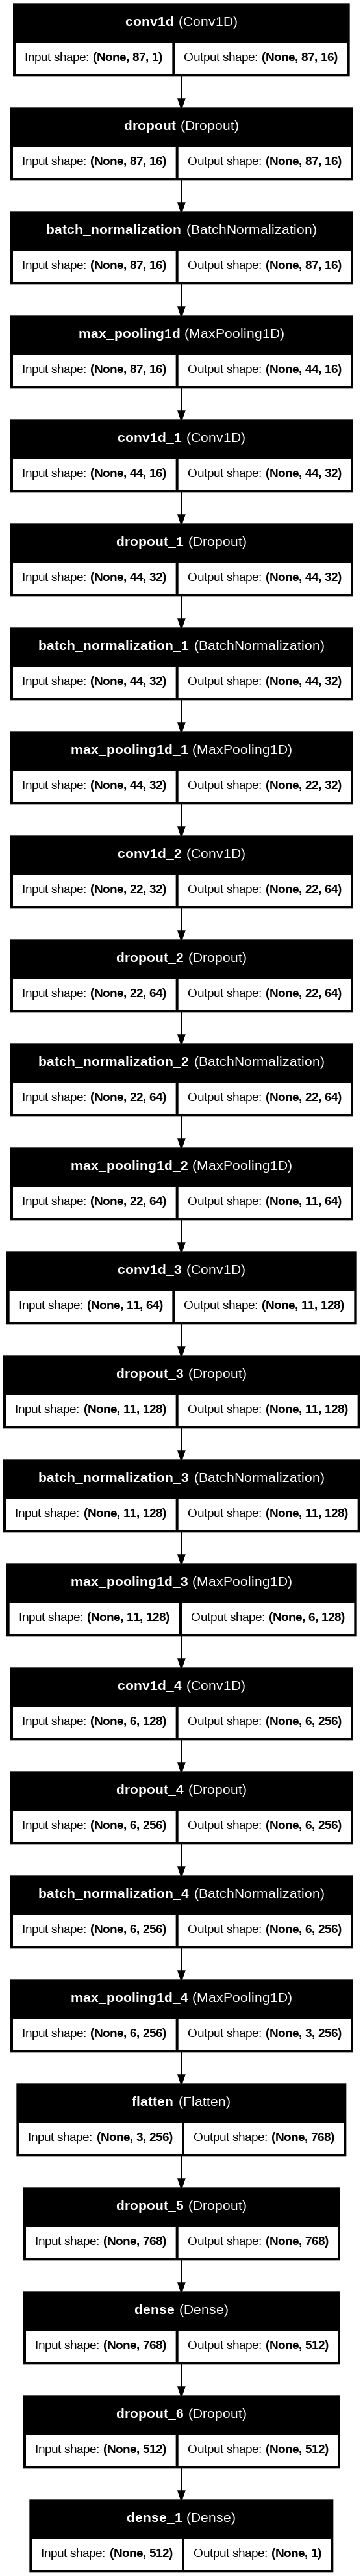

In [ ]:
# Vẽ sơ đồ mô hình CNN_model1
plot_model(CNN_model1, to_file='CNN_model1.png', show_shapes=True, show_layer_names=True, dpi=96)

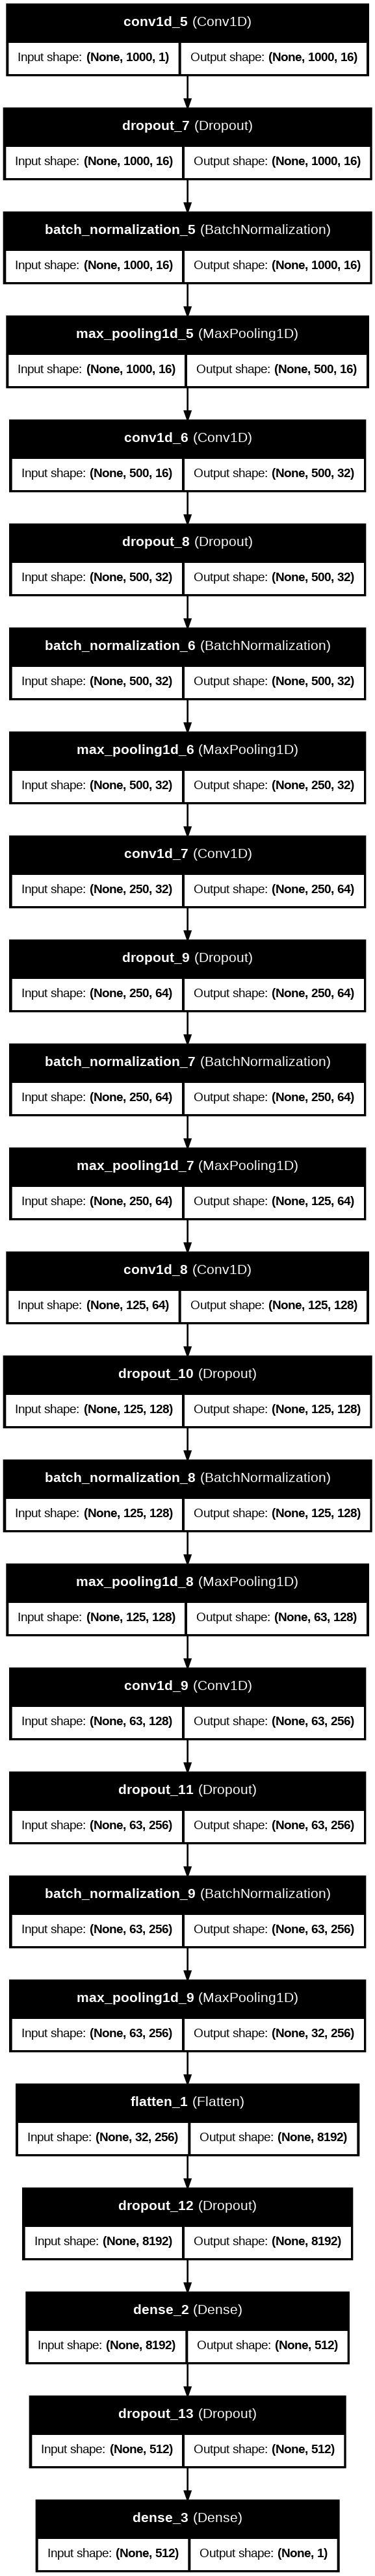

In [ ]:
# Vẽ sơ đồ mô hình CNN_model2
plot_model(CNN_model2, to_file='CNN_model2.png', show_shapes=True, show_layer_names=True, dpi=96)

# CNN MODEL ON FIRST DATASET

In [ ]:
CNN_model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

callbacks = [tf.keras.callbacks.ModelCheckpoint('CNN_MODEL_ON_FEATURE_EXTRACTED.h5',verbose=1,save_best_only=True),
             tf.keras.callbacks.EarlyStopping(monitor='val_loss',min_delta=0.001,patience=30,verbose=1)]
CNN_results_1 = CNN_model1.fit(X_train1,Y_train1,validation_split=0.2,batch_size=128,epochs=200,callbacks=callbacks)

Epoch 1/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8850 - loss: 0.2923
Epoch 1: val_loss improved from inf to 2.43402, saving model to CNN_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.8848 - loss: 0.2924 - val_accuracy: 0.5036 - val_loss: 2.4340
Epoch 2/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8844 - loss: 0.2826
Epoch 2: val_loss improved from 2.43402 to 1.69117, saving model to CNN_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.8842 - loss: 0.2829 - val_accuracy: 0.5036 - val_loss: 1.6912
Epoch 3/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8718 - loss: 0.3087
Epoch 3: val_loss did not improve from 1.69117
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8720 - loss: 0.3081 - val_accuracy: 0.5036 - val_loss: 2.5456
Epoch 4/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8861 - loss: 0.2791 
Epoch 4: val_loss did not improve from 1.69117
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.8862 - loss: 0.2793 - val_accuracy: 0.5036 - val_loss: 2.6894
Epoch 5/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8878 - loss: 0.2772
Epoch 5: val_loss did not improve from 1.69117
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8877 - loss: 0.2772 - val_accuracy: 0.5036 - val_loss: 3.6665
Epoch 6/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8843 - loss: 0.2824
Epoch 6: val_loss did not improve from 1.69117
5

58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8948 - loss: 0.2575 - val_accuracy: 0.5046 - val_loss: 1.5803
Epoch 16/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8903 - loss: 0.2658
Epoch 16: val_loss improved from 1.58032 to 0.92013, saving model to CNN_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.8904 - loss: 0.2655 - val_accuracy: 0.5714 - val_loss: 0.9201
Epoch 17/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8954 - loss: 0.2596
Epoch 17: val_loss did not improve from 0.92013
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.8954 - loss: 0.2595 - val_accuracy: 0.5325 - val_loss: 1.1197
Epoch 18/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9014 - loss: 0.2417 
Epoch 18: val_loss improved from 0.92013 to 0.71168, saving model to CNN_MODEL_ON_FEATURE_EXTRACTED.h5


...

58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9028 - loss: 0.2455 - val_accuracy: 0.9360 - val_loss: 0.1887
Epoch 35/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9043 - loss: 0.2345
Epoch 35: val_loss improved from 0.18865 to 0.17940, saving model to CNN_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.9043 - loss: 0.2345 - val_accuracy: 0.9360 - val_loss: 0.1794
Epoch 36/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9044 - loss: 0.2322
Epoch 36: val_loss improved from 0.17940 to 0.17319, saving model to CNN_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.9045 - loss: 0.2323 - val_accuracy: 0.9355 - val_loss: 0.1732
Epoch 37/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9067 - loss: 0.2292
Epoch 37: val_loss did not improve from 0.17319
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9066 - loss: 0.2294 - val_accuracy: 0.9382 - val_loss: 0.1887
Epoch 38/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9093 - loss: 0.2398
Epoch 38: val_loss did not improve from 0.17319
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9093 - loss: 0.2396 - val_accuracy: 0.9355 - val_loss: 0.1795
Epoch 39/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9031 - loss: 0.2481 
Epoch 39: val_loss did not improve from 0.17319
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9032 - loss: 0.2477 - val_accuracy: 0.9207 - val_loss: 0.2176
Epoch 40/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8975 - loss: 0.2552
Epoch 40: val_loss did not improve from 

58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9082 - loss: 0.2279 - val_accuracy: 0.9366 - val_loss: 0.1727
Epoch 48/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9133 - loss: 0.2182
Epoch 48: val_loss did not improve from 0.17270
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.9133 - loss: 0.2183 - val_accuracy: 0.9360 - val_loss: 0.1758
Epoch 49/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9044 - loss: 0.2335
Epoch 49: val_loss did not improve from 0.17270
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.9045 - loss: 0.2333 - val_accuracy: 0.9366 - val_loss: 0.1770
Epoch 50/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9112 - loss: 0.2126
Epoch 50: val_loss did not improve from 0.17270
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9111 - loss: 0.2130 - val_accuracy: 0.9114 - val_loss: 0.2248
Epoch 51/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9114 - loss: 0.2231
Epoch 51: val_loss did not improve from 0.1

58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.9086 - loss: 0.2359 - val_accuracy: 0.9404 - val_loss: 0.1627
Epoch 55/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9172 - loss: 0.2134
Epoch 55: val_loss did not improve from 0.16270
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9170 - loss: 0.2136 - val_accuracy: 0.9399 - val_loss: 0.1724
Epoch 56/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9118 - loss: 0.2191
Epoch 56: val_loss did not improve from 0.16270
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.9117 - loss: 0.2191 - val_accuracy: 0.9382 - val_loss: 0.1688
Epoch 57/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9097 - loss: 0.2229
Epoch 57: val_loss did not improve from 0.16270
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9098 - loss: 0.2228 - val_accuracy: 0.9333 - val_loss: 0.1877
Epoch 58/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9101 - loss: 0.2170
Epoch 58: val_loss did not improve from 0.1

In [ ]:
CNN_model1.evaluate(X_test1,Y_test1,verbose = 1)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9347 - loss: 0.1943


[0.1919037401676178, 0.9356955289840698]

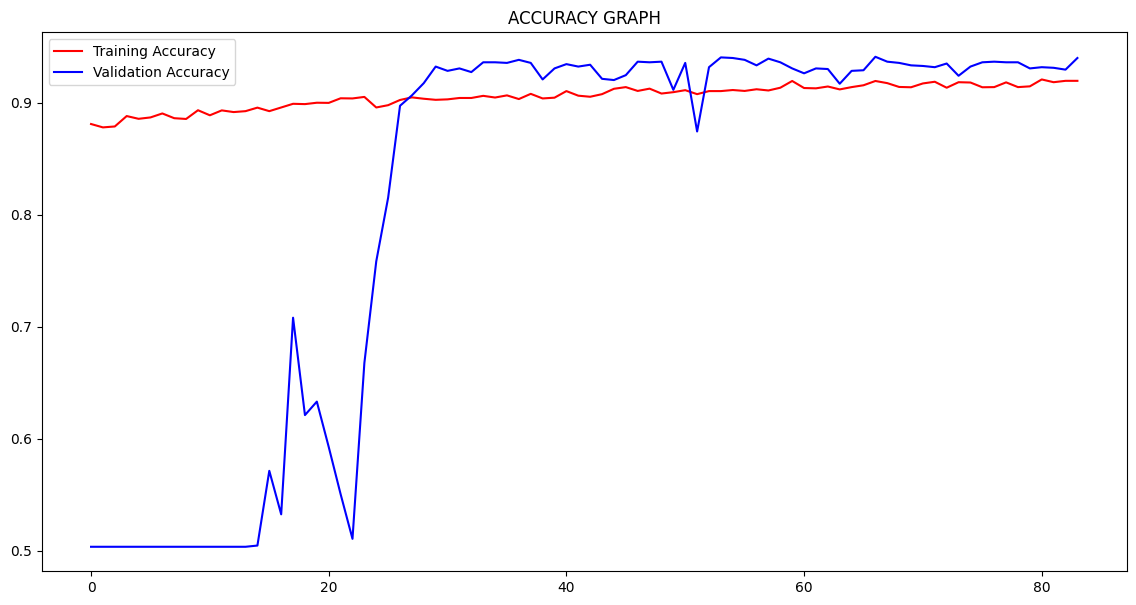

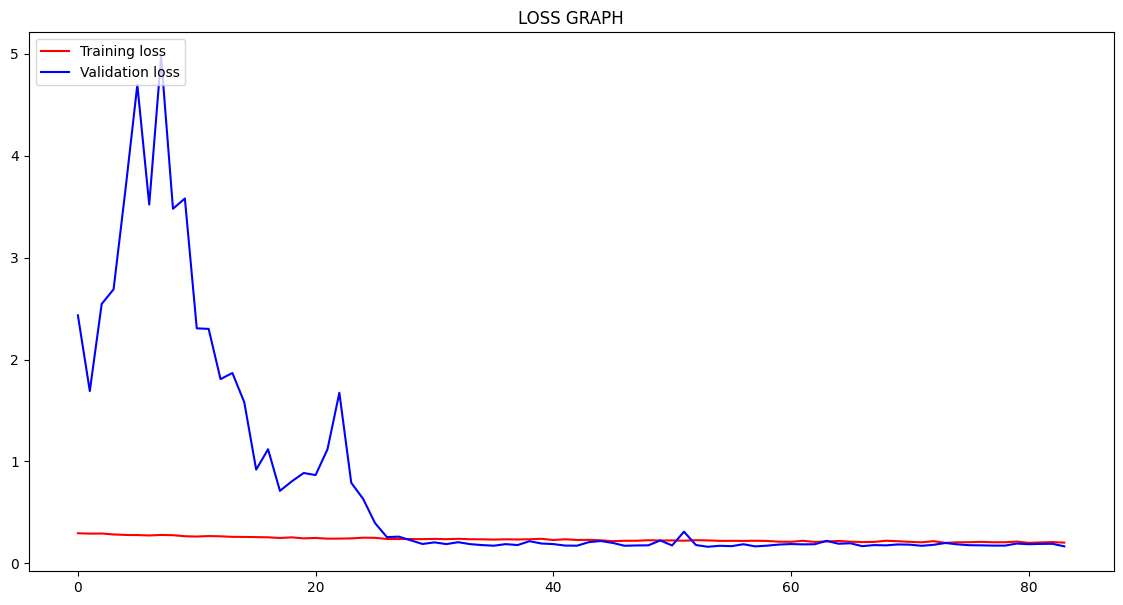

In [ ]:
eval_graph(CNN_results_1)

In [ ]:
Y_test1

,labels
6172,1
9810,1
8537,1
605,1
6549,0
...,...
4104,0
6374,0
6232,0
3950,0


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


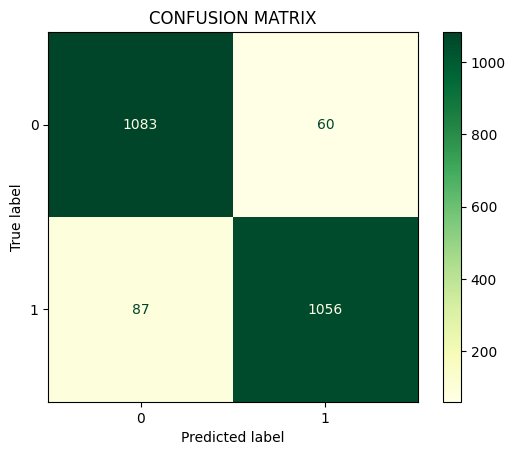

In [ ]:
conf_matrix(X_test1,Y_test1,CNN_model1)

# CNN MODEL ON SECOND DATASET

In [ ]:
CNN_model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

callbacks = [tf.keras.callbacks.ModelCheckpoint('CNN_MODEL_ON_NON_FEATURE_EXTRACTED.h5',verbose=1,save_best_only=True),
             tf.keras.callbacks.EarlyStopping(monitor='val_loss',min_delta=0.001,patience=30,verbose=1)]
CNN_results_2 = CNN_model2.fit(X_train2,Y_train2,validation_split=0.2,batch_size=128,epochs=200,callbacks=callbacks)

Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9160 - loss: 0.2034
Epoch 1: val_loss improved from inf to 0.27194, saving model to CNN_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 821ms/step - accuracy: 0.9159 - loss: 0.2036 - val_accuracy: 0.8950 - val_loss: 0.2719
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.9131 - loss: 0.2131
Epoch 2: val_loss did not improve from 0.27194
58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 828ms/step - accuracy: 0.9131 - loss: 0.2130 - val_accuracy: 0.8923 - val_loss: 0.3023
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9202 - loss: 0.1933
Epoch 3: val_loss did not improve from 0.27194
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 780ms/step - accuracy: 0.9201 - loss: 0.1933 - val_accuracy: 0.9027 - val_loss: 0.2800
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9219 - loss: 0.1908
Epoch 4: val_loss improved from 0.27194 to 0.26534, saving model to CNN_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 85s 837ms/step - accuracy: 0.9220 - loss: 0.1907 - val_accuracy: 0.8885 - val_loss: 0.2653
Epoch 5/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.9304 - loss: 0.1760
Epoch 5: val_loss improved from 0.26534 to 0.25737, saving model to CNN_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 800ms/step - accuracy: 0.9304 - loss: 0.1760 - val_accuracy: 0.9027 - val_loss: 0.2574
Epoch 6/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.9357 - loss: 0.1624
Epoch 6: val_loss did not improve from 0.25737
58/58 ━━━━━━━━━━━━━━━━━━━━ 81s 779ms/step - accuracy: 0.9356 - loss: 0.1625 - val_accuracy: 0.8989 - val_loss: 0.2758
Epoch 7/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.9327 - loss: 0.1595
Epoch 7: val_loss did not improve from 0.25737
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 794ms/step - accuracy: 0.9326 - loss: 0.1597 - val_accuracy: 0.9010 - val_loss: 0.3072
Epoch 8/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.9344 - loss: 0.1524
Epoch 8: val_loss did not improve from 0.25737
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 793ms/step - accuracy: 0.9344 - loss: 0.1525 - val_accuracy: 0.9060 - val_loss: 0.2805
Epoch 9/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.9383 - loss: 0.1497
Epoch 9: val_loss did not improve from 

In [ ]:
CNN_model2.evaluate(X_test2,Y_test2,verbose = 1)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9234 - loss: 0.3090


[0.35769906640052795, 0.9125109314918518]

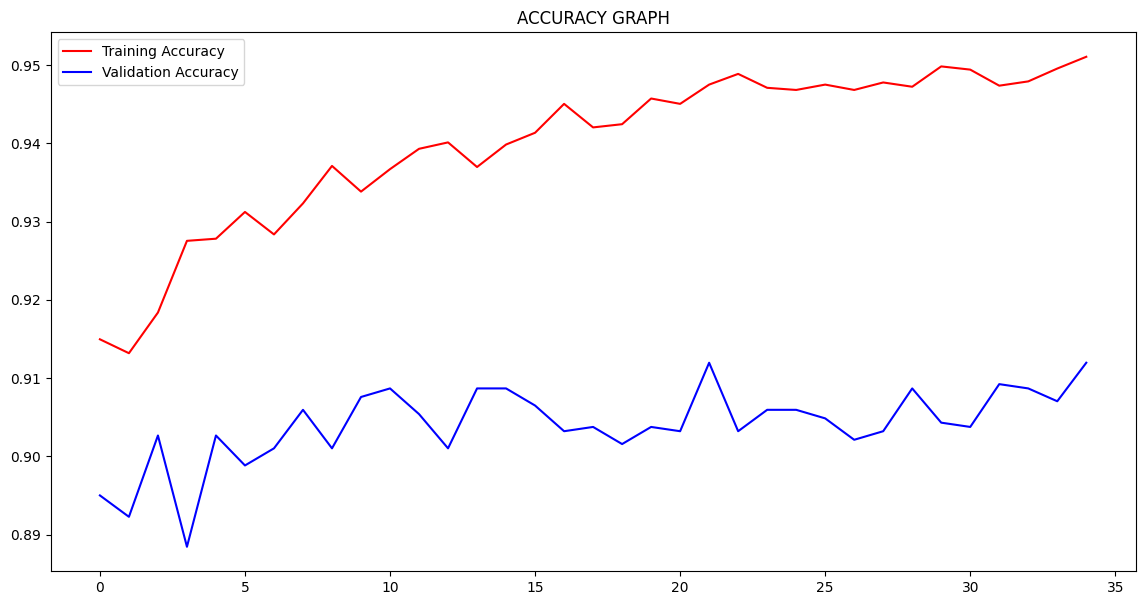

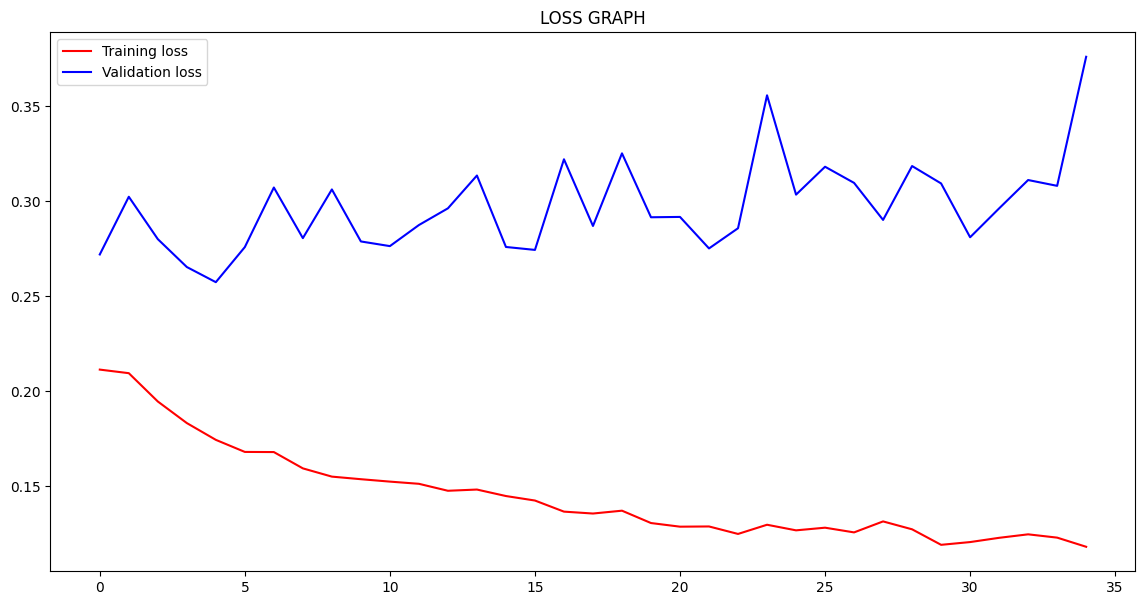

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


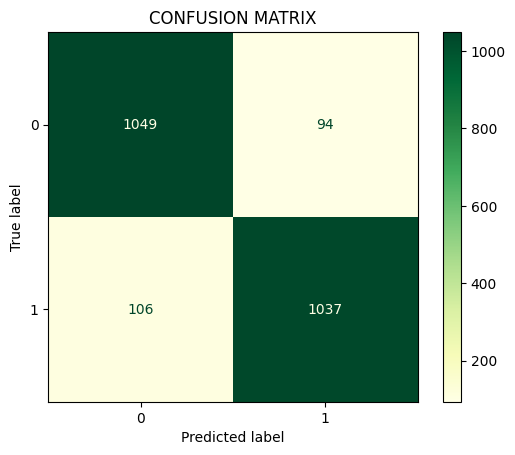

In [ ]:
eval_graph(CNN_results_2)
conf_matrix(X_test2,Y_test2,CNN_model2)

# CNN LSTM MODEL

In [ ]:
def CNN_LSTM(input_size):
    model = keras.Sequential()
    model.add(layers.Input(input_size))
    model.add(layers.Conv1D(filters = 16,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 32,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 64,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 128,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size = 2,padding = 'same'))
    model.add(layers.Conv1D(filters = 256,kernel_size = 3,activation = 'relu',padding = 'same'))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.LSTM(128,return_sequences=True))
    model.add(layers.Dropout(0.3))
    model.add(layers.Flatten())
    model.add(layers.Dense(128,activation = 'relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(128,activation = 'relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1,activation = 'sigmoid'))

    return model

CNN_LSTM_model1 = CNN_LSTM(input_size1)
CNN_LSTM_model1.summary()
CNN_LSTM_model2 = CNN_LSTM(input_size2)
CNN_LSTM_model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 87, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 87, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 87, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 44, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 44, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 44, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 44, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 22, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 22, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 11, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 6, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 445,281 (1.70 MB)

 Trainable params: 444,289 (1.69 MB)

 Non-trainable params: 992 (3.88 KB)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 1000, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 1000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 500, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 500, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 250, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 125, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 63, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 63, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 63, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 63, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8064)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,379,169 (5.26 MB)

 Trainable params: 1,378,177 (5.26 MB)

 Non-trainable params: 992 (3.88 KB)

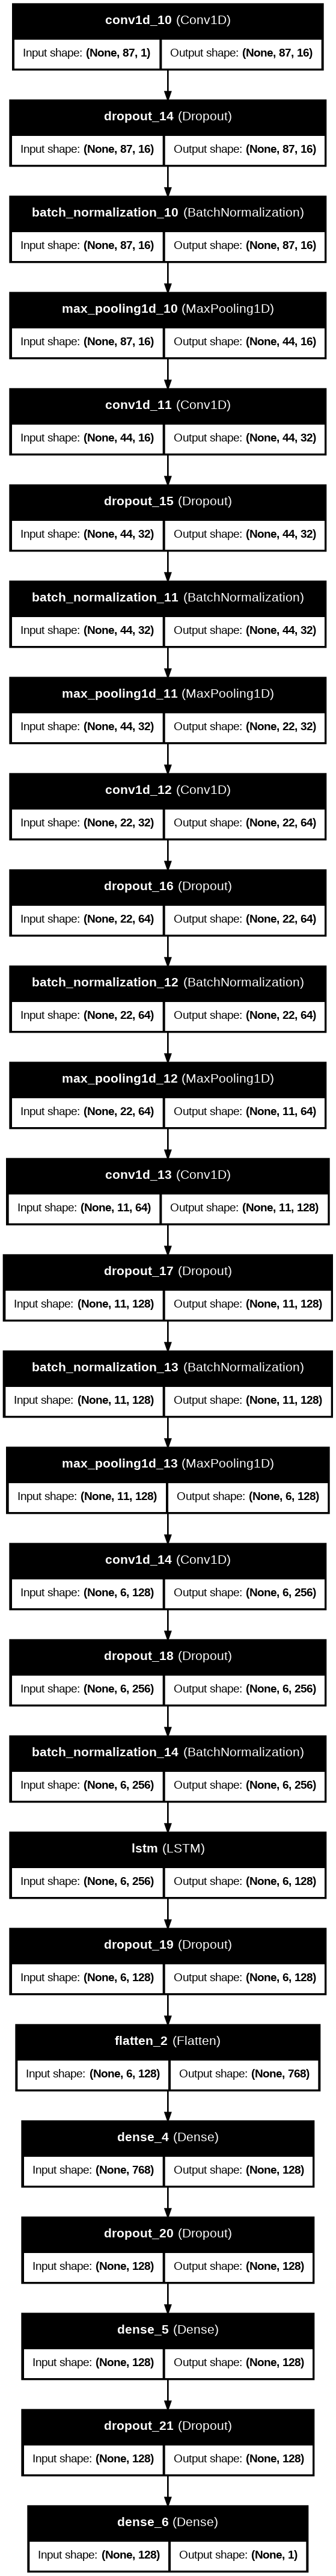

In [ ]:
# Vẽ sơ đồ mô hình CNN_LSTM_model1
plot_model(CNN_LSTM_model1, to_file='CNN_LSTM_model1.png', show_shapes=True, show_layer_names=True, dpi=96)

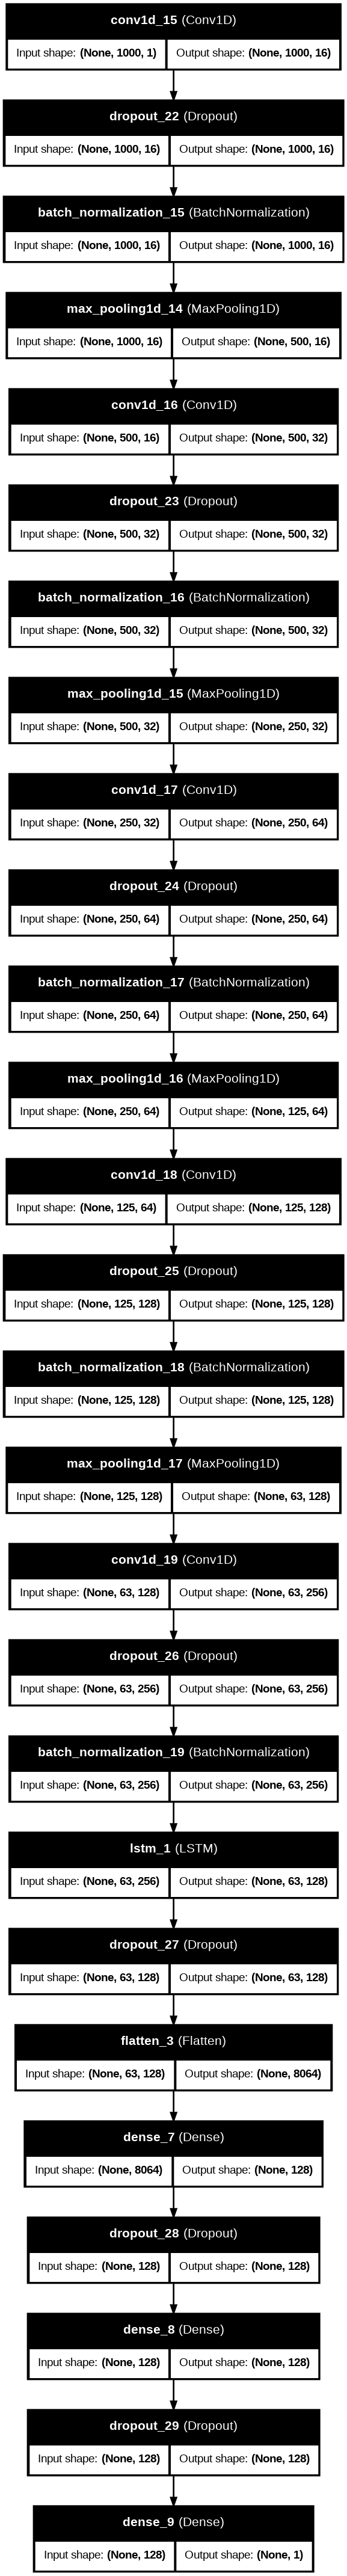

In [ ]:
# Vẽ sơ đồ mô hình CNN_LSTM_model2
plot_model(CNN_LSTM_model2, to_file='CNN_LSTM_model2.png', show_shapes=True, show_layer_names=True, dpi=96)

# CNN LSTM MODEL ON FIRST DATASET

In [ ]:
CNN_LSTM_model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

callbacks = [tf.keras.callbacks.ModelCheckpoint('CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5',verbose=1,save_best_only=True),
             tf.keras.callbacks.EarlyStopping(monitor='val_loss',min_delta=0.001,patience=30,verbose=1)]
CNN_LSTM_results_1 = CNN_LSTM_model1.fit(X_train1,Y_train1,validation_split=0.2,batch_size=128,epochs=200,callbacks=callbacks)

Epoch 1/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9133 - loss: 0.2161
Epoch 1: val_loss improved from inf to 0.36614, saving model to CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.9131 - loss: 0.2165 - val_accuracy: 0.8491 - val_loss: 0.3661
Epoch 2/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9065 - loss: 0.2322
Epoch 2: val_loss improved from 0.36614 to 0.32359, saving model to CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.9065 - loss: 0.2322 - val_accuracy: 0.8655 - val_loss: 0.3236
Epoch 3/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9098 - loss: 0.2235
Epoch 3: val_loss improved from 0.32359 to 0.24420, saving model to CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.9099 - loss: 0.2235 - val_accuracy: 0.9038 - val_loss: 0.2442
Epoch 4/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9152 - loss: 0.2109
Epoch 4: val_loss did not improve from 0.24420
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9150 - loss: 0.2114 - val_accuracy: 0.8967 - val_loss: 0.2509
Epoch 5/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9157 - loss: 0.2098
Epoch 5: val_loss did not improve from 0.24420
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9156 - loss: 0.2101 - val_accuracy: 0.7813 - val_loss: 0.5064
Epoch 6/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9129 - loss: 0.2232
Epoch 6: val_loss improved from 0.24420 to 0.23791, saving model to CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.9127 - loss: 0.2235 - val_accuracy: 0.9103 - val_loss: 0.2379
Epoch 7/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9024 - loss: 0.2443
Epoch 7: val_loss did not improve from 0.23791
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.9026 - loss: 0.2438 - val_accuracy: 0.8321 - val_loss: 0.3964
Epoch 8/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9103 - loss: 0.2254
Epoch 8: val_loss did not improve from 0.23791
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9103 - loss: 0.2256 - val_accuracy: 0.8852 - val_loss: 0.2749
Epoch 9/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9098 - loss: 0.2276
Epoch 9: val_loss improved from 0.23791 to 0.23439, saving model to CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5


...

58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9110 - loss: 0.2214 - val_accuracy: 0.9207 - val_loss: 0.2220
Epoch 18/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9120 - loss: 0.2229
Epoch 18: val_loss did not improve from 0.22203
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9119 - loss: 0.2229 - val_accuracy: 0.8272 - val_loss: 0.4292
Epoch 19/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9065 - loss: 0.2289
Epoch 19: val_loss did not improve from 0.22203
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9067 - loss: 0.2287 - val_accuracy: 0.8710 - val_loss: 0.3317
Epoch 20/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9074 - loss: 0.2230
Epoch 20: val_loss did not improve from 0.22203
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.9076 - loss: 0.2228 - val_accuracy: 0.8639 - val_loss: 0.3434
Epoch 21/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9180 - loss: 0.2149
Epoch 21: val_loss did not improve from 

58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9176 - loss: 0.2101 - val_accuracy: 0.9103 - val_loss: 0.2206
Epoch 30/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9164 - loss: 0.2148
Epoch 30: val_loss did not improve from 0.22058
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9163 - loss: 0.2147 - val_accuracy: 0.9021 - val_loss: 0.2449
Epoch 31/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9208 - loss: 0.2116
Epoch 31: val_loss improved from 0.22058 to 0.21742, saving model to CNN_LSTM_MODEL_ON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9206 - loss: 0.2116 - val_accuracy: 0.9196 - val_loss: 0.2174
Epoch 32/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9156 - loss: 0.2078
Epoch 32: val_loss did not improve from 0.21742
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.9156 - loss: 0.2077 - val_accuracy: 0.8212 - val_loss: 0.4206
Epoch 33/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9199 - loss: 0.2082
Epoch 33: val_loss did not improve from 0.21742
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.9198 - loss: 0.2085 - val_accuracy: 0.8097 - val_loss: 0.4481
Epoch 34/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9190 - loss: 0.2100
Epoch 34: val_loss did not improve from 0.21742
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.9189 - loss: 0.2100 - val_accuracy: 0.7403 - val_loss: 0.6371
Epoch 35/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9191 - loss: 0.2031
Epoch 35: val_loss did not improve f

58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9206 - loss: 0.2032 - val_accuracy: 0.9218 - val_loss: 0.2140
Epoch 51/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9225 - loss: 0.1931
Epoch 51: val_loss did not improve from 0.21399
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.9225 - loss: 0.1933 - val_accuracy: 0.8382 - val_loss: 0.3928
Epoch 52/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9188 - loss: 0.2145
Epoch 52: val_loss did not improve from 0.21399
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9188 - loss: 0.2144 - val_accuracy: 0.7775 - val_loss: 0.5211
Epoch 53/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9261 - loss: 0.1916
Epoch 53: val_loss did not improve from 0.21399
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.9261 - loss: 0.1918 - val_accuracy: 0.9142 - val_loss: 0.2292
Epoch 54/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9206 - loss: 0.2077
Epoch 54: val_loss did not improve from

58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.9243 - loss: 0.2043 - val_accuracy: 0.9196 - val_loss: 0.2120
Epoch 68/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9199 - loss: 0.2075
Epoch 68: val_loss did not improve from 0.21203
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9199 - loss: 0.2074 - val_accuracy: 0.7862 - val_loss: 0.5159
Epoch 69/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9228 - loss: 0.1995
Epoch 69: val_loss did not improve from 0.21203
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.9227 - loss: 0.1995 - val_accuracy: 0.9235 - val_loss: 0.2225
Epoch 70/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9221 - loss: 0.1975
Epoch 70: val_loss did not improve from 0.21203
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9220 - loss: 0.1976 - val_accuracy: 0.8409 - val_loss: 0.4128
Epoch 71/200
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9200 - loss: 0.2019
Epoch 71: val_loss did not improve from 

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8675 - loss: 0.3657


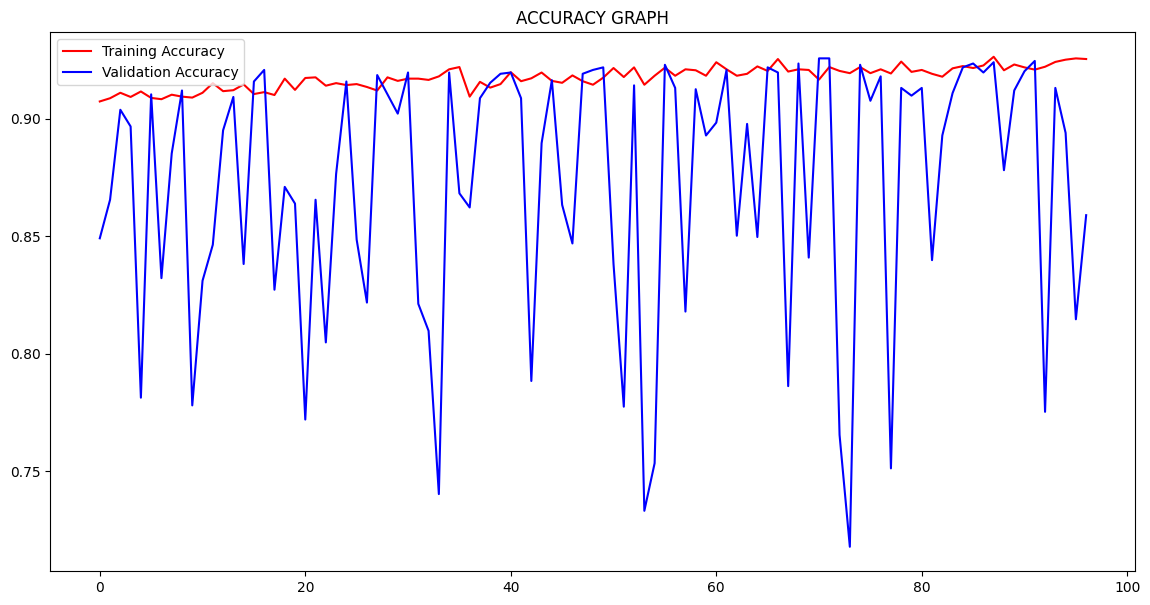

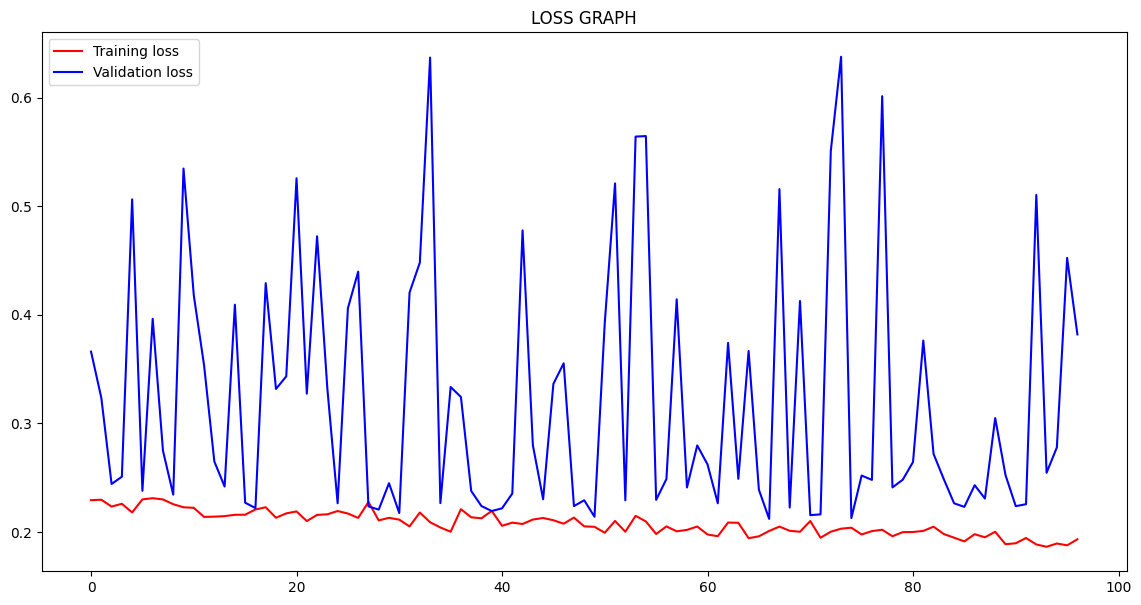

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


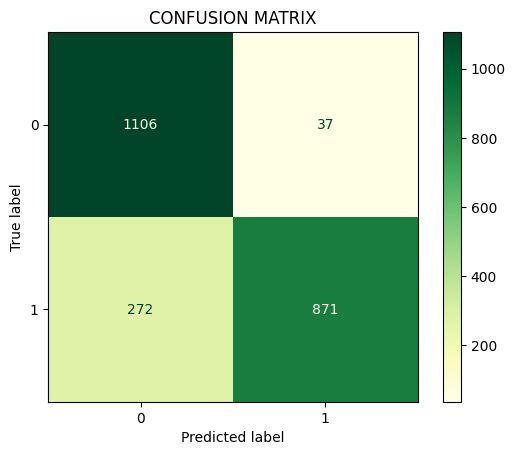

In [ ]:
CNN_LSTM_model1.evaluate(X_test1,Y_test1)
eval_graph(CNN_LSTM_results_1)
conf_matrix(X_test1,Y_test1,CNN_LSTM_model1)

# CNN LSTM MODEL ON SECOND DATASET

In [ ]:
CNN_LSTM_model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

callbacks = [tf.keras.callbacks.ModelCheckpoint('CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5',verbose=1,save_best_only=True),
             tf.keras.callbacks.EarlyStopping(monitor='val_loss',min_delta=0.001,patience=30,verbose=1)]
CNN_LSTM_results_2 = CNN_LSTM_model2.fit(X_train2,Y_train2,validation_split=0.2,batch_size=128,epochs=200,callbacks=callbacks)

Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.6550 - loss: 0.6090
Epoch 1: val_loss improved from inf to 0.73857, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 60s 888ms/step - accuracy: 0.6561 - loss: 0.6079 - val_accuracy: 0.5036 - val_loss: 0.7386
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.7947 - loss: 0.4567
Epoch 2: val_loss improved from 0.73857 to 0.69068, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 937ms/step - accuracy: 0.7948 - loss: 0.4565 - val_accuracy: 0.6709 - val_loss: 0.6907
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.8186 - loss: 0.4152
Epoch 3: val_loss did not improve from 0.69068
58/58 ━━━━━━━━━━━━━━━━━━━━ 80s 901ms/step - accuracy: 0.8187 - loss: 0.4149 - val_accuracy: 0.5036 - val_loss: 0.7347
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - accuracy: 0.8397 - loss: 0.3642
Epoch 4: val_loss did not improve from 0.69068
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 902ms/step - accuracy: 0.8397 - loss: 0.3642 - val_accuracy: 0.5036 - val_loss: 0.6986
Epoch 5/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.8540 - loss: 0.3357
Epoch 5: val_loss improved from 0.69068 to 0.64163, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 898ms/step - accuracy: 0.8539 - loss: 0.3358 - val_accuracy: 0.6145 - val_loss: 0.6416
Epoch 6/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.8641 - loss: 0.3092
Epoch 6: val_loss improved from 0.64163 to 0.58596, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 898ms/step - accuracy: 0.8641 - loss: 0.3092 - val_accuracy: 0.6922 - val_loss: 0.5860
Epoch 7/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.8823 - loss: 0.2855
Epoch 7: val_loss improved from 0.58596 to 0.52687, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


...

58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 911ms/step - accuracy: 0.9161 - loss: 0.2096 - val_accuracy: 0.8770 - val_loss: 0.2761
Epoch 13/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9132 - loss: 0.1961
Epoch 13: val_loss improved from 0.27607 to 0.26158, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 907ms/step - accuracy: 0.9132 - loss: 0.1961 - val_accuracy: 0.8945 - val_loss: 0.2616
Epoch 14/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.9244 - loss: 0.1918
Epoch 14: val_loss did not improve from 0.26158
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 906ms/step - accuracy: 0.9245 - loss: 0.1916 - val_accuracy: 0.8907 - val_loss: 0.2691
Epoch 15/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9257 - loss: 0.1723
Epoch 15: val_loss improved from 0.26158 to 0.25317, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 83s 926ms/step - accuracy: 0.9256 - loss: 0.1725 - val_accuracy: 0.8956 - val_loss: 0.2532
Epoch 16/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.9308 - loss: 0.1704
Epoch 16: val_loss did not improve from 0.25317
58/58 ━━━━━━━━━━━━━━━━━━━━ 81s 906ms/step - accuracy: 0.9307 - loss: 0.1705 - val_accuracy: 0.8792 - val_loss: 0.2754
Epoch 17/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.9276 - loss: 0.1652
Epoch 17: val_loss did not improve from 0.25317
58/58 ━━━━━━━━━━━━━━━━━━━━ 83s 924ms/step - accuracy: 0.9276 - loss: 0.1652 - val_accuracy: 0.9076 - val_loss: 0.2571
Epoch 18/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.9256 - loss: 0.1753
Epoch 18: val_loss improved from 0.25317 to 0.25201, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 933ms/step - accuracy: 0.9256 - loss: 0.1753 - val_accuracy: 0.9065 - val_loss: 0.2520
Epoch 19/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9331 - loss: 0.1618
Epoch 19: val_loss did not improve from 0.25201
58/58 ━━━━━━━━━━━━━━━━━━━━ 80s 899ms/step - accuracy: 0.9331 - loss: 0.1618 - val_accuracy: 0.9010 - val_loss: 0.2665
Epoch 20/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.9345 - loss: 0.1546
Epoch 20: val_loss did not improve from 0.25201
58/58 ━━━━━━━━━━━━━━━━━━━━ 84s 927ms/step - accuracy: 0.9344 - loss: 0.1547 - val_accuracy: 0.9049 - val_loss: 0.2577
Epoch 21/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9414 - loss: 0.1445
Epoch 21: val_loss improved from 0.25201 to 0.25080, saving model to CNN_LSTM_MODEL_ON_NON_FEATURE_EXTRACTED.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 926ms/step - accuracy: 0.9413 - loss: 0.1447 - val_accuracy: 0.9071 - val_loss: 0.2508
Epoch 22/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9403 - loss: 0.1527
Epoch 22: val_loss did not improve from 0.25080
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 923ms/step - accuracy: 0.9403 - loss: 0.1527 - val_accuracy: 0.9049 - val_loss: 0.2564
Epoch 23/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.9418 - loss: 0.1464
Epoch 23: val_loss did not improve from 0.25080
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 925ms/step - accuracy: 0.9417 - loss: 0.1465 - val_accuracy: 0.9043 - val_loss: 0.2642
Epoch 24/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9436 - loss: 0.1347
Epoch 24: val_loss did not improve from 0.25080
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 923ms/step - accuracy: 0.9436 - loss: 0.1348 - val_accuracy: 0.9043 - val_loss: 0.2623
Epoch 25/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9465 - loss: 0.1322
Epoch 25: val_loss did not impro

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9220 - loss: 0.2705


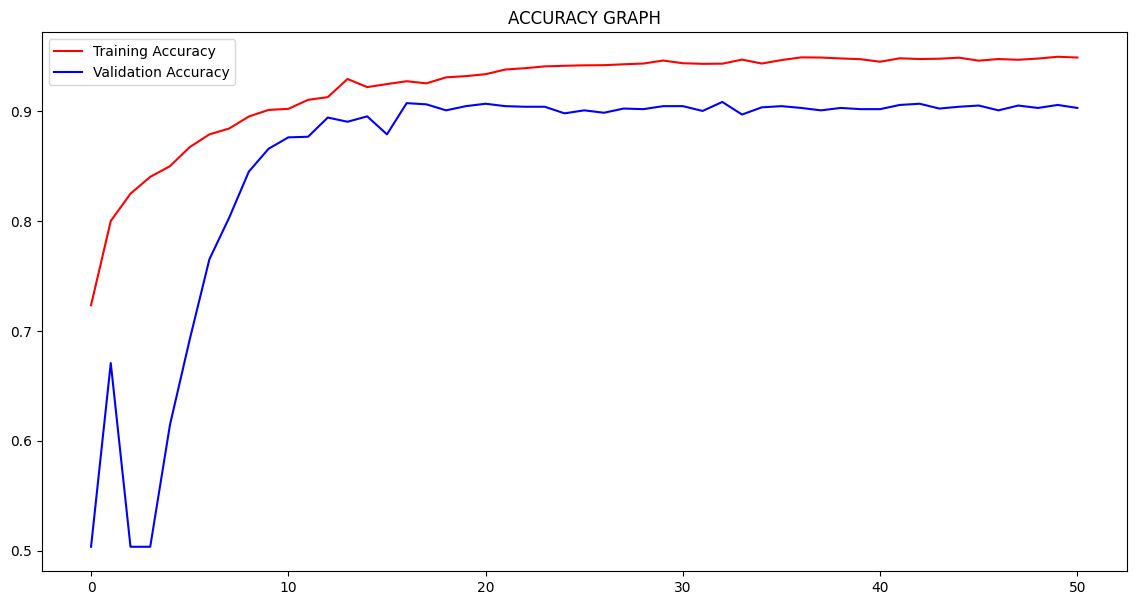

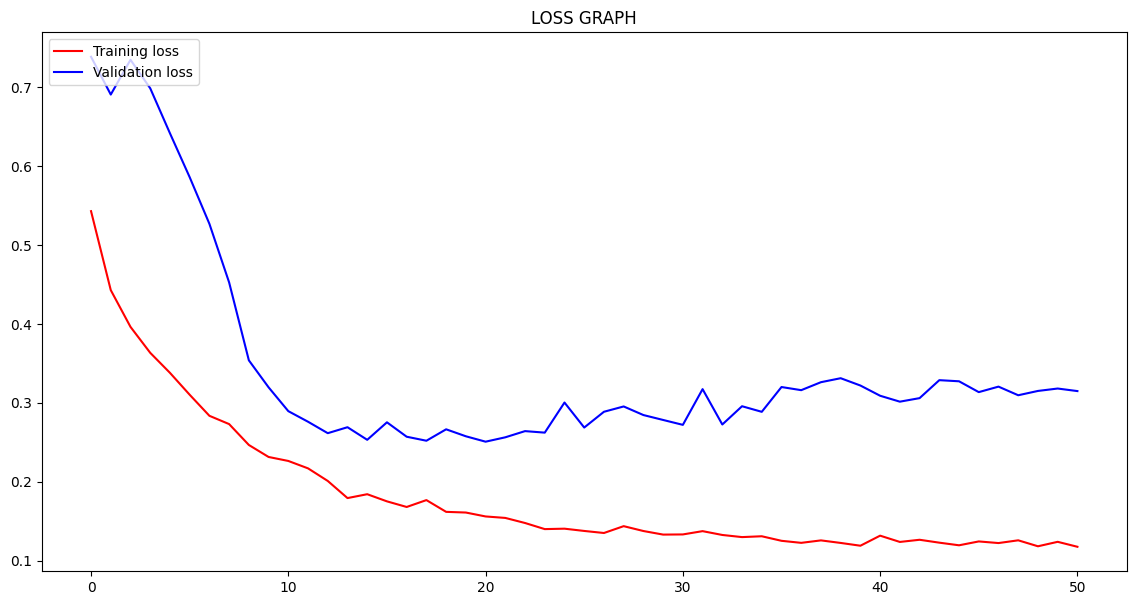

72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step


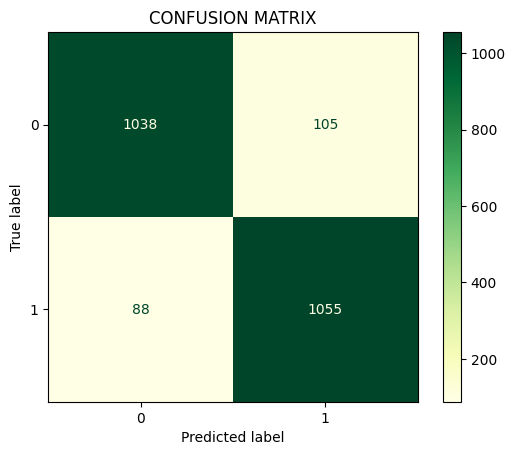

In [ ]:
CNN_LSTM_model2.evaluate(X_test2,Y_test2)
eval_graph(CNN_LSTM_results_2)
conf_matrix(X_test2,Y_test2,CNN_LSTM_model2)

# TRANSFORMER MODEL

In [33]:
# Định nghĩa mô hình Transformer
class Transformer(nn.Module):
    def __init__(self, transformer):
        super(Transformer, self).__init__()
        self.transformer = transformer
        self.fc = nn.Sequential(
            nn.Linear(768, 512),  # 768 từ BERT pooler output
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask, numerical_features=None):
        transformer_output = self.transformer(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        return self.fc(transformer_output)

# Khởi tạo mô hình Transformers BERT model
transformer_model = BertModel.from_pretrained('bert-base-uncased')
transformer_model_only = Transformer(transformer_model)

summary(transformer_model_only, input_data=input_data)

Layer (type:depth-idx)                                       Output Shape              Param #
Transformer                                                  [1, 1]                    --
├─BertModel: 1-1                                             [1, 768]                  --
│    └─BertEmbeddings: 2-1                                   [1, 64, 768]              --
│    │    └─Embedding: 3-1                                   [1, 64, 768]              23,440,896
│    │    └─Embedding: 3-2                                   [1, 64, 768]              1,536
│    │    └─Embedding: 3-3                                   [1, 64, 768]              393,216
│    │    └─LayerNorm: 3-4                                   [1, 64, 768]              1,536
│    │    └─Dropout: 3-5                                     [1, 64, 768]              --
│    └─BertEncoder: 2-2                                      [1, 64, 768]              --
│    │    └─ModuleList: 3-6                                  --             

# TRANFORMER MODEL ON FIRST DATASET

In [ ]:
# Hàm huấn luyện mô hình Transformer
def train_model(model, train_loader, test_loader, model_name, epochs=10):
    model.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    # Đóng băng các tầng BERT trừ 2 tầng cuối
    for param in model.transformer.parameters():
        param.requires_grad = False
    for param in model.transformer.encoder.layer[-2:].parameters():
        param.requires_grad = True
    for param in model.transformer.pooler.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predictions = (outputs >= 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        train_accuracy = correct / total
        history['loss'].append(avg_loss)
        history['accuracy'].append(train_accuracy)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predictions = (outputs >= 0.5).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(test_loader)
        val_accuracy = correct / total
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)

        print(f'{model_name} - Epoch {epoch + 1}, Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

        torch.save(model.state_dict(), f'{model_name}_ON_NON_FEATURES.pth')

        # Giải phóng bộ nhớ
        torch.cuda.empty_cache()
        gc.collect()

    return history

In [ ]:
transformer_results = train_model(
    transformer_model_only,
    train_loader_trans,
    test_loader_trans,
    'TRANSFORMER_MODEL',
    epochs=10
)
transformer_model_only.eval()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

TRANSFORMER_MODEL - Epoch 1, Loss: 0.4168, Train Accuracy: 0.8180, Val Loss: 0.2275, Val Accuracy: 0.9116
TRANSFORMER_MODEL - Epoch 2, Loss: 0.2441, Train Accuracy: 0.9000, Val Loss: 0.1908, Val Accuracy: 0.9265
TRANSFORMER_MODEL - Epoch 3, Loss: 0.2103, Train Accuracy: 0.9166, Val Loss: 0.1871, Val Accuracy: 0.9361
TRANSFORMER_MODEL - Epoch 4, Loss: 0.1869, Train Accuracy: 0.9265, Val Loss: 0.1731, Val Accuracy: 0.9409
TRANSFORMER_MODEL - Epoch 5, Loss: 0.1771, Train Accuracy: 0.9309, Val Loss: 0.1567, Val Accuracy: 0.9418
TRANSFORMER_MODEL - Epoch 6, Loss: 0.1559, Train Accuracy: 0.9428, Val Loss: 0.1490, Val Accuracy: 0.9458
TRANSFORMER_MODEL - Epoch 7, Loss: 0.1403, Train Accuracy: 0.9483, Val Loss: 0.1493, Val Accuracy: 0.9475
TRANSFORMER_MODEL - Epoch 8, Loss: 0.1310, Train Accuracy: 0.9505, Val Loss: 0.1520, Val Accuracy: 0.9497
TRANSFORMER_MODEL - Epoch 9, Loss: 0.1137, Train Accuracy: 0.9587, Val Loss: 0.1562, Val Accuracy: 0.9466
TRANSFORMER_MODEL - Epoch 10, Loss: 0.1153, Tr

NameError: name 'conf_matrix' is not defined

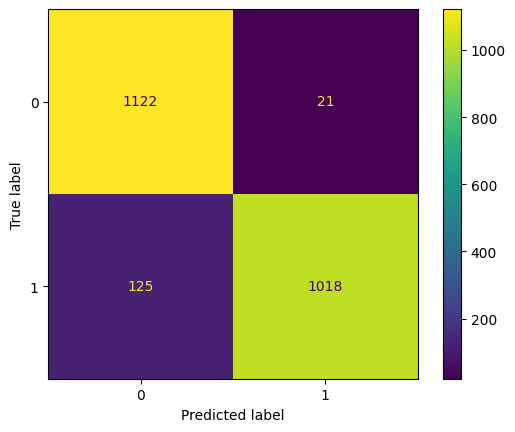

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1143
           1       0.98      0.89      0.93      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



AttributeError: 'dict' object has no attribute 'history'

In [ ]:
conf_matrix1(test_loader_trans, Y_test3, transformer_model_only)


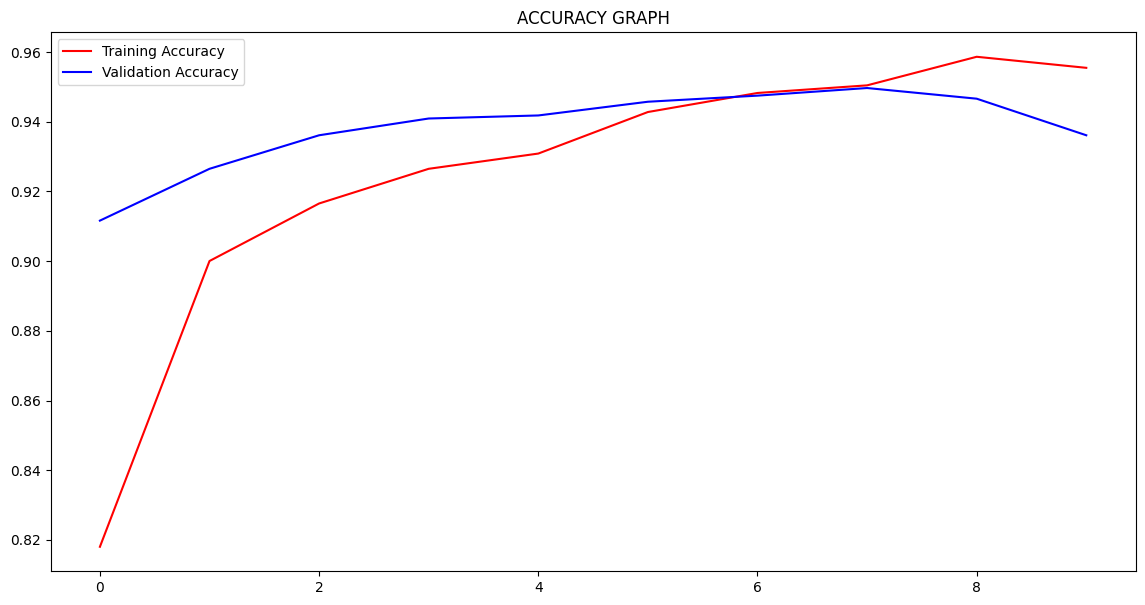

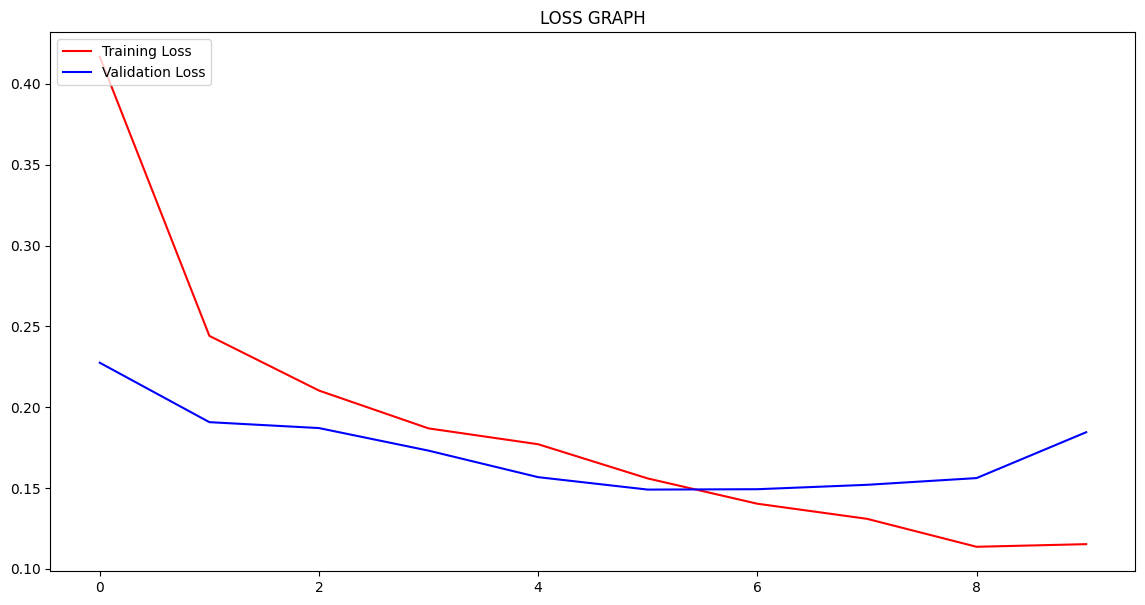

In [ ]:
eval_graph1(transformer_results)

# CHUYỂN FILE .ipynb SANG .pdf

In [34]:
!pip install nbconvert

In [ ]:
!pip install --upgrade nbconvert ipywidgets
!apt-get install pandoc texlive-xetex

In [ ]:
!jupyter nbconvert --to pdf /content/drive/MyDrive/Colab Notebooks/LSTM-CNN-Transformer-Phising-Website-Detection.ipynb

Streaming output truncated to the last 5000 lines.
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There is no ━ (U+2501) in font [lmmono10-regular]:!
Missing character: There i